In [1]:
import sys
from pathlib import Path
import wandb

In [2]:
cfg = {
    'project_name': 'unet_base_train',
    'num_epochs': 200,
    'batch_size': 10,
    'batches_per_epoch': 50,
    'learning_rate': 1e-3,
    'architecture': 'monai-UNet-64-4-4',
    'dataset': 'prostate',
    'datapath': '/data/Data/PMRI',
    'data_key': 'image',
    'seg_key': 'label',
    'vendor': 'siemens',
    'n_chans_in': 1,
    'n_chans_out': 2
}

In [3]:
wandb.init(
    project=cfg['project_name'],
    config={
        "learning_rate": cfg['learning_rate'],
        "architecture": cfg['architecture'],
        "dataset": cfg['dataset'],
        "epochs": cfg['num_epochs'],
        "batch_size": cfg['batch_size'],
        "batches_per_epoch": cfg['batches_per_epoch']
    }
)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: segomezru (sgomezr). Use `wandb login --relogin` to force relogin


In [4]:
base_path = Path('/workspace/src').resolve()
src_path = base_path / 'src'
pmri_data_path = Path('/data/Data/PMRI').resolve()
sys.path.append(str(src_path))

In [5]:
from datasets import load_dataset
data = load_dataset(cfg, ['train', 'valid'])
ds_train = data['train']
ds_valid = data['valid']

Loading dataset...
Loading dataset...


In [6]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import optim, nn
from monai.networks.nets import DynUNet
from monai.data import DataLoader, Dataset
from monai.transforms import (
    CastToTyped,
    Compose,
    EnsureTyped,
    RandFlipd,
    RandGaussianNoised,
    RandGaussianSmoothd,
    RandScaleIntensityd,
    RandZoomd,
    SpatialPadd,
    ToTensord,
)

#### Transforms flipd axis test

In [7]:
tr0 = Compose([
    ToTensord(keys=['image', 'label']),
    RandFlipd(keys=['image', 'label'], spatial_axis=[0], prob=1.0),
])
tr1 = Compose([
    ToTensord(keys=['image', 'label']),
    RandFlipd(keys=['image', 'label'], spatial_axis=[1], prob=1.0),
])

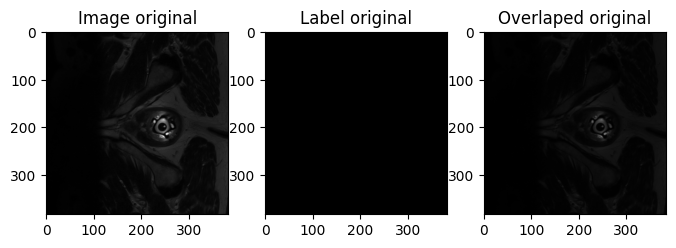

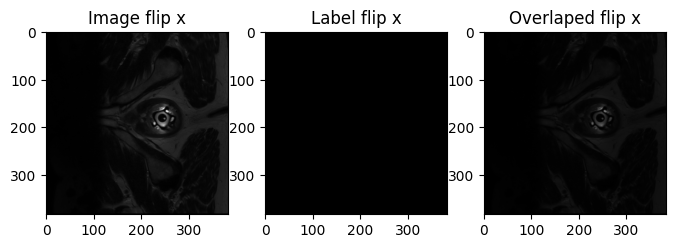

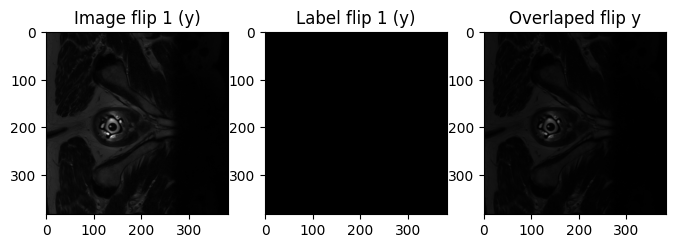

In [8]:
fig, axs = plt.subplots(1,3, figsize=(8,8))
axs[0].imshow(ds_train[0]['image'].squeeze(), cmap='gray')
axs[0].set_title('Image original')
axs[1].imshow(ds_train[0]['label'].squeeze(), cmap='gray')
axs[1].set_title('Label original')
axs[2].imshow(ds_train[0]['image'].squeeze(), cmap='gray')
axs[2].imshow(ds_train[0]['label'].squeeze(), cmap='gray', alpha=0.5)
axs[2].set_title('Overlaped original')
plt.show();
fig, axs = plt.subplots(1,3, figsize=(8,8))
tmp = tr0(ds_train[0])
axs[0].imshow(tmp['image'].squeeze(), cmap='gray')
axs[0].set_title('Image flip x')
axs[1].imshow(tmp['label'].squeeze(), cmap='gray')
axs[1].set_title('Label flip x')
axs[2].imshow(tmp['image'].squeeze(), cmap='gray')
axs[2].imshow(tmp['label'].squeeze(), cmap='gray', alpha=0.5)
axs[2].set_title('Overlaped flip x')
plt.show();
fig, axs = plt.subplots(1,3, figsize=(8,8))
tmp = tr1(ds_train[0])
axs[0].imshow(tmp['image'].squeeze(), cmap='gray')
axs[0].set_title('Image flip 1 (y)')
axs[1].imshow(tmp['label'].squeeze(), cmap='gray')
axs[1].set_title('Label flip 1 (y)')
axs[2].imshow(tmp['image'].squeeze(), cmap='gray')
axs[2].imshow(tmp['label'].squeeze(), cmap='gray', alpha=0.5)
axs[2].set_title('Overlaped flip y')
plt.show();

#### Actual test UNet

In [9]:
# transforms = Compose([
#     ToTensord(keys=['image', 'label']),
#     SpatialPadd(keys=['image', 'label'], spatial_size=ds_train._DS_CONFIG['size']),
#     RandZoomd(keys=['image', 'label'], min_zoom=0.9, max_zoom=1.2,
#               mode=('trilinear', 'nearest'), align_corners=(True, None), prob=0.15),
#     RandGaussianNoised(keys=['image'], std=0.01, prob=0.15),
#     RandGaussianSmoothd(keys=['image'], sigma_x=(0.5, 1.15),
#                         sigma_y=(0.5, 1.15), prob=0.15),
#     RandScaleIntensityd(keys=['image'], factors=0.3, prob=0.15),
#     RandFlipd(keys=['image', 'label'], spatial_axis=[0], prob=0.5),
#     RandFlipd(keys=['image', 'label'], spatial_axis=[1], prob=0.5),
#     CastToTyped(keys=['image', 'label'], dtype=(np.float32, torch.long)),
#     EnsureTyped(keys=['image', 'label'])
# ])

In [10]:
from data_utils import Transform
from trainer import train_loop
from models import get_model

In [11]:
transforms = Transform(cfg)
dst = Dataset(ds_train, transform=transforms['all_transforms'])
dsv = Dataset(ds_valid, transform=transforms['base_transforms'])
dlt = DataLoader(dst, shuffle=True, batch_size=cfg['batch_size'])
dlv = DataLoader(dsv, batch_size=cfg['batch_size'])

In [12]:
device = torch.device('cuda:2')
unet = get_model(cfg)
unet.to(device)
optimizer = optim.Adam(unet.parameters(), lr=cfg['learning_rate'])
loss_function = nn.CrossEntropyLoss()

In [13]:
training_stats = train_loop(
    model=unet,
    train_loader=dlt,
    val_loader=dlv,
    optimizer=optimizer,
    criterion=loss_function,
    device=device,
    cfg=cfg,
    log=True
)

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 46.00 MiB. GPU 0 has a total capacity of 11.90 GiB of which 26.94 MiB is free. Process 562756 has 9.57 GiB memory in use. Process 724562 has 2.30 GiB memory in use. Of the allocated memory 2.10 GiB is allocated by PyTorch, and 47.84 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# torch.save(net.state_dict(), 'testnet.pth')